# Paso 1: Definición del problema (Adaptado a Last.fm)

El problema de negocio:
Queremos saber qué factores hacen que una canción sea muy escuchada. ¿Es la duración? ¿Es el género musical (etiquetas)? ¿Es la popularidad general del artista?
Vamos a crear un modelo de Machine Learning que prediga si una canción será un "Hit" (alta popularidad) o "Estándar" (baja/media popularidad) basándonos en sus características.

¿Cómo lo convertimos en un problema de Machine Learning?
Será un problema de Clasificación.

A)_ Variable Objetivo (Target): En Last.fm, cada canción tiene un número de listeners (oyentes únicos) y playcount (reproducciones totales). Podemos definir que un "Hit" es una canción que supera cierto número de oyentes, clasificándolas en 1 (Hit) y 0 (No Hit).

B)_ Variables Predictoras (Features): Para cumplir el requisito de las 20 variables (incluyendo categóricas), podemos extraer:

_Nombre del artista (Categórica)

_Duración de la canción en milisegundos (Numérica)

_Oyentes totales del artista en la plataforma (Numérica)

_¿Tiene videoclip / está en Youtube? (Booleana/Categórica - algunos endpoints lo dan)

_al 20+. Las Etiquetas (Tags): Last.fm funciona con tags generados por usuarios ('rock', 'pop', 'female vocalists', '80s', 'acoustic', etc.). Tomaremos los 15-20 tags más populares de la plataforma y crearemos columnas binarias (1 si la canción tiene el tag 'rock', 0 si no).

# Paso 2: Obtención y carga del conjunto de datos

Para cumplir con la extracción de datos reales, usaremos la API pública de Last.fm.

In [1]:
import requests
import pandas as pd
import time
import os

API_KEY = 'c6975e1301d5981858f13766aa0b5774'
USER_AGENT = 'ProyectoBootcamp_Javier'
ARCHIVO_SALIDA = 'dataset_lastfm_60k_seguro.csv'

# Si existe un archivo de una prueba anterior, lo borramos para empezar limpios
if os.path.exists(ARCHIVO_SALIDA):
    os.remove(ARCHIVO_SALIDA)

print("Fase 1: Obteniendo lista de los 1.500 artistas más populares...")
lista_artistas = []

for pagina in range(1, 4):
    url_artistas = f"http://ws.audioscrobbler.com/2.0/?method=chart.gettopartists&api_key={API_KEY}&format=json&page={pagina}&limit=500"
    try:
        respuesta = requests.get(url_artistas, headers={'User-Agent': USER_AGENT})
        if respuesta.status_code == 200:
            datos = respuesta.json()
            artistas = datos['artists']['artist']
            for artista in artistas:
                lista_artistas.append(artista['name'])
    except Exception as e:
        print(f"Error al obtener artistas en página {pagina}: {e}")
    time.sleep(1)

print(f"¡Éxito! Se han encontrado {len(lista_artistas)} artistas distintos.")
print("\nFase 2: Extrayendo canciones con GUARDADO SEGURO...")

datos_temporales = [] # Usaremos esta lista como un "camión de carga" pequeño

# Recorremos la lista de artistas
for indice, artista in enumerate(lista_artistas):
    if indice % 50 == 0:
        print(f"Procesando artista {indice} de {len(lista_artistas)}: {artista}...")
        
    url_canciones = f"http://ws.audioscrobbler.com/2.0/?method=artist.gettoptracks&artist={artista}&api_key={API_KEY}&format=json&limit=50"
    
    try:
        respuesta = requests.get(url_canciones, headers={'User-Agent': USER_AGENT}, timeout=10)
        if respuesta.status_code == 200:
            datos = respuesta.json()
            canciones = datos.get('toptracks', {}).get('track', [])
            
            for cancion in canciones:
                datos_temporales.append({
                    'nombre_cancion': cancion.get('name'),
                    'nombre_artista': artista,
                    'oyentes': int(cancion.get('listeners') or 0),
                    'reproducciones': int(cancion.get('playcount') or 0),
                    'url': cancion.get('url')
                })
    except Exception as e:
        pass 
        
    time.sleep(1) # Pausa obligatoria
    
    # --- EL TRUCO SALVAVIDAS ---
    # Cada 50 artistas, o si es el último artista de la lista, volcamos los datos al CSV
    if (indice + 1) % 50 == 0 or (indice + 1) == len(lista_artistas):
        if datos_temporales:
            df_temp = pd.DataFrame(datos_temporales)
            
            # Si el archivo no existe, añade las cabeceras. Si ya existe, solo añade datos (mode='a')
            es_nuevo = not os.path.exists(ARCHIVO_SALIDA)
            df_temp.to_csv(ARCHIVO_SALIDA, mode='a', index=False, header=es_nuevo, encoding='utf-8')
            
            # Vaciamos el "camión" para liberar la memoria RAM
            datos_temporales = []

print(f"\n¡Extracción segura terminada! Todos tus datos están en '{ARCHIVO_SALIDA}'.")

# Leemos el archivo final para ver cuántas filas conseguimos realmente
df_final = pd.read_csv(ARCHIVO_SALIDA)
df_final = df_final.drop_duplicates(subset=['nombre_cancion', 'nombre_artista'])
df_final.to_csv(ARCHIVO_SALIDA, index=False) # Guardamos la versión sin duplicados

print(f"Total de filas únicas conseguidas: {len(df_final)}")

Fase 1: Obteniendo lista de los 1.500 artistas más populares...
¡Éxito! Se han encontrado 1500 artistas distintos.

Fase 2: Extrayendo canciones con GUARDADO SEGURO...
Procesando artista 0 de 1500: PinkPantheress...
Procesando artista 50 de 1500: Beyoncé...
Procesando artista 100 de 1500: ABBA...
Procesando artista 150 de 1500: bôa...
Procesando artista 200 de 1500: Big Thief...
Procesando artista 250 de 1500: Strawberry Guy...
Procesando artista 300 de 1500: Two Door Cinema Club...
Procesando artista 350 de 1500: Bon Jovi...
Procesando artista 400 de 1500: Surf Curse...
Procesando artista 450 de 1500: i-dle...
Procesando artista 500 de 1500: The Fray...
Procesando artista 550 de 1500: A Tribe Called Quest...
Procesando artista 600 de 1500: Arcane...
Procesando artista 650 de 1500: Beach Bunny...
Procesando artista 700 de 1500: American Football...
Procesando artista 750 de 1500: Lloyd...
Procesando artista 800 de 1500: Feid...
Procesando artista 850 de 1500: Shaggy...
Procesando artis

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = se

Procesando artista 1100 de 1500: MASS OF THE FERMENTING DREGS...


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.

Procesando artista 1150 de 1500: Milo j...
Procesando artista 1200 de 1500: Mike...
Procesando artista 1250 de 1500: Coolio...
Procesando artista 1300 de 1500: Sheena Ringo...
Procesando artista 1350 de 1500: Indila...
Procesando artista 1400 de 1500: 88rising...
Procesando artista 1450 de 1500: Rubel...

¡Extracción segura terminada! Todos tus datos están en 'dataset_lastfm_60k_seguro.csv'.
Total de filas únicas conseguidas: 68368


In [ ]:
import numpy as np

API_KEY = 'c6975e1301d5981858f13766aa0b5774'
USER_AGENT = 'ProyectoBootcamp_Javier'
ARCHIVO_DATOS = 'dataset_lastfm_60k_seguro.csv'
ARCHIVO_FINAL = 'dataset_lastfm_ML_listo.csv'

# Cargamos nuestros datos conseguidos
print("Cargando las 68.000 canciones...")
df = pd.read_csv(ARCHIVO_DATOS)
artistas_unicos = df['nombre_artista'].dropna().unique()

print(f"Tenemos {len(artistas_unicos)} artistas únicos. Vamos a buscar sus géneros musicales...")

datos_tags_artistas = []

# Extraemos los tags de los artistas (Tardará unos 20-25 mins)
for indice, artista in enumerate(artistas_unicos):
    if indice % 100 == 0:
        print(f"Buscando tags para el artista {indice} de {len(artistas_unicos)}...")
        
    url_tags = f"http://ws.audioscrobbler.com/2.0/?method=artist.gettoptags&artist={artista}&api_key={API_KEY}&format=json"
    
    try:
        respuesta = requests.get(url_tags, headers={'User-Agent': USER_AGENT}, timeout=10)
        if respuesta.status_code == 200:
            datos = respuesta.json()
            tags = datos.get('toptags', {}).get('tag', [])
            
            # Cogemos solo los 5 géneros principales de este artista para no saturarnos
            top_5_tags = [t['name'].lower() for t in tags[:5]]
            
            # Guardamos esta información
            info_artista = {'nombre_artista': artista}
            for tag in top_5_tags:
                info_artista[f'tag_{tag}'] = 1 # Ponemos un 1 en la columna de ese género
            
            datos_tags_artistas.append(info_artista)
    except Exception as e:
        pass 
        
    time.sleep(1) # Pausa obligatoria

# Juntamos todo en un DataFrame de Tags
df_tags = pd.DataFrame(datos_tags_artistas).fillna(0) # Rellenamos los vacíos con 0

# Para no tener 5000 columnas de géneros raros, nos quedamos solo con los 20 géneros más repetidos
frecuencia_tags = df_tags.drop('nombre_artista', axis=1).sum().sort_values(ascending=False)
top_20_columnas_tags = frecuencia_tags.head(20).index.tolist()
columnas_a_mantener = ['nombre_artista'] + top_20_columnas_tags
df_tags_filtrado = df_tags[columnas_a_mantener]

# Unimos los géneros a nuestras canciones originales (JOIN)
print("\nUniendo géneros a las canciones...")
df_final = pd.merge(df, df_tags_filtrado, on='nombre_artista', how='left').fillna(0)

# CREAMOS EL TARGET
# Calculamos la mediana de oyentes. Si tiene más oyentes que la mediana, es un HIT (1), si no, es 0.
mediana_oyentes = df_final['oyentes'].median()
df_final['es_hit'] = np.where(df_final['oyentes'] > mediana_oyentes, 1, 0)

# Variables extra para asegurar las 20+ variables
df_final['longitud_nombre_cancion'] = df_final['nombre_cancion'].astype(str).apply(len)
df_final['longitud_nombre_artista'] = df_final['nombre_artista'].astype(str).apply(len)
df_final['ratio_reproducciones_oyentes'] = df_final['reproducciones'] / (df_final['oyentes'] + 1) # +1 para evitar dividir por 0

# Guardamos el archivo maestro
df_final.to_csv(ARCHIVO_FINAL, index=False)

print(f"\n¡PROCESO COMPLETADO! 🎉")
print(f"Filas totales: {df_final.shape[0]}")
print(f"Columnas totales (Variables): {df_final.shape[1]}")
print(f"Tu archivo final listo para el EDA es: '{ARCHIVO_FINAL}'")

Cargando las 68.000 canciones...
Tenemos 1370 artistas únicos. Vamos a buscar sus géneros musicales...
Buscando tags para el artista 0 de 1370...
Buscando tags para el artista 100 de 1370...
Buscando tags para el artista 200 de 1370...
Buscando tags para el artista 300 de 1370...
Buscando tags para el artista 400 de 1370...
Buscando tags para el artista 500 de 1370...
Buscando tags para el artista 600 de 1370...
Buscando tags para el artista 700 de 1370...
Buscando tags para el artista 800 de 1370...
Buscando tags para el artista 900 de 1370...
Buscando tags para el artista 1000 de 1370...
Buscando tags para el artista 1100 de 1370...
Buscando tags para el artista 1200 de 1370...
Buscando tags para el artista 1300 de 1370...

Uniendo géneros a las canciones...

¡PROCESO COMPLETADO! 🎉
Filas totales: 68368
Columnas totales (Variables): 29
Tu archivo final listo para el EDA es: 'dataset_lastfm_ML_listo.csv'


# Paso 3: Almacenar la información.

In [ ]:
import sqlite3
import pandas as pd

ARCHIVO_FINAL = 'dataset_lastfm_ML_listo.csv'

# Nos conectamos a la base de datos (si no existe, SQLite la crea al instante)
print("Conectando a la base de datos SQL 'lastfm_music.db'...")
conexion = sqlite3.connect('lastfm_music.db')
cursor = conexion.cursor()

# Leemos CSV maestro
df_maestro = pd.read_csv(ARCHIVO_FINAL)

# Separamos los datos en DOS tablas
print("Creando e insertando datos en las tablas 'artistas' y 'canciones'...")

# Tabla 1: Solo información de los artistas
df_artistas = df_maestro[['nombre_artista', 'longitud_nombre_artista']].drop_duplicates()
# Tabla 2: Información de las canciones y sus géneros (sin la longitud del nombre del artista)
df_canciones = df_maestro.drop(columns=['longitud_nombre_artista'])

# Al usar to_sql, Pandas hace los 'INSERT' masivos por detrás automáticamente
df_artistas.to_sql('artistas', conexion, if_exists='replace', index=False)
df_canciones.to_sql('canciones', conexion, if_exists='replace', index=False)

# Demostramos el uso de INSERT manual con código SQL puro
consulta_insert = "INSERT INTO artistas (nombre_artista, longitud_nombre_artista) VALUES ('DJ Javier Bootcamp', 18);"
cursor.execute(consulta_insert)
conexion.commit()
print("✅ INSERT manual ejecutado con éxito.")

# Hacemos consultas de valor usando SELECT y JOIN (usando el wrapper read_sql_query de Pandas)
print("\n--- CONSULTA DE NEGOCIO: Top 5 canciones 'Hit' con más reproducciones y su info de artista ---")

consulta_join = """
    SELECT 
        c.nombre_cancion, 
        c.reproducciones, 
        c.oyentes,
        a.nombre_artista, 
        a.longitud_nombre_artista
    FROM canciones c
    JOIN artistas a ON c.nombre_artista = a.nombre_artista
    WHERE c.es_hit = 1
    ORDER BY c.reproducciones DESC
    LIMIT 5;
"""

# Ejecutamos la consulta y la mostramos de forma
resultado_join = pd.read_sql_query(consulta_join, conexion)
print(resultado_join.to_markdown(index=False))

# Otra consulta de valor: ¿Cuántos Hits y No Hits tenemos en total?
consulta_agrupada = """
    SELECT 
        es_hit, 
        COUNT(*) as total_canciones,
        AVG(oyentes) as promedio_oyentes
    FROM canciones
    GROUP BY es_hit;
"""
print("\n--- CONSULTA DE NEGOCIO: Distribución de nuestra Variable Objetivo (Target) ---")
resultado_agrupada = pd.read_sql_query(consulta_agrupada, conexion)
print(resultado_agrupada.to_markdown(index=False))

# Cerramos la conexión por buenas prácticas
conexion.close()

Conectando a la base de datos SQL 'lastfm_music.db'...
Creando e insertando datos en las tablas 'artistas' y 'canciones'...
✅ INSERT manual ejecutado con éxito.

--- CONSULTA DE NEGOCIO: Top 5 canciones 'Hit' con más reproducciones y su info de artista ---
| nombre_cancion        |   reproducciones |   oyentes | nombre_artista   |   longitud_nombre_artista |
|:----------------------|-----------------:|----------:|:-----------------|--------------------------:|
| Don’t Say You Love Me |        282096112 |    256078 | Jin              |                         3 |
| Who                   |        239767776 |    462313 | Jimin            |                         5 |
| Haegeum               |        230167563 |    406229 | Agust D          |                         7 |
| Like Crazy            |        202657870 |    476715 | Jimin            |                         5 |
| Dynamite              |        173756636 |   1055844 | BTS              |                         3 |

--- CONSULTA D

# Paso 4: Análisis Descriptivo.

--- 1. ESTADÍSTICOS DESCRIPTIVOS BÁSICOS ---


,oyentes,reproducciones,ratio_reproducciones_oyentes,longitud_nombre_cancion
count,68368.00,6.836800e+04,68368.00,68368.00
mean,172130.07,1.613592e+06,7.38,16.68
std,274652.45,4.319637e+06,9.82,12.05
min,1.00,1.000000e+00,0.50,1.00
25%,27963.25,1.410638e+05,4.37,9.00
50%,76851.50,4.843425e+05,6.09,13.00
75%,193879.75,1.454846e+06,8.64,21.00
max,4032672.00,2.820961e+08,1101.60,254.00



--- 2. DISTRIBUCIÓN DE LAS VARIABLES ---
Teoría: Las variables de popularidad (oyentes/reproducciones) siguen una distribución de 'Larga Cola' (Asimetría Positiva).
La mayoría de canciones tienen pocos oyentes, y unos pocos 'superhits' tienen millones.


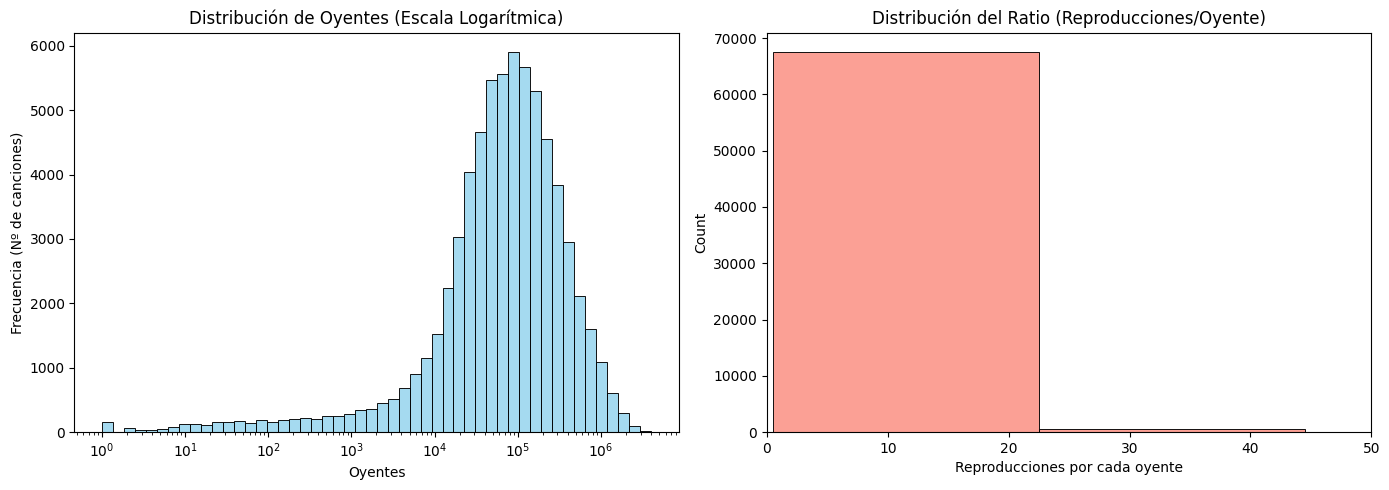


--- 3. CONTRASTE DE HIPÓTESIS ---
Estadístico T: 33.0034
P-valor: 1.4771e-236

👉 CONCLUSIÓN: Como el P-valor es menor que 0.05, RECHAZAMOS la Hipótesis Nula.
Esto significa que hay una diferencia estadísticamente significativa en el ratio de repetición.
Media de repeticiones en Hits: 8.61 veces por oyente.
Media de repeticiones en No Hits: 6.15 veces por oyente.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargamos nuestros datos limpios
ARCHIVO_FINAL = 'dataset_lastfm_ML_listo.csv'
df = pd.read_csv(ARCHIVO_FINAL)

# MEDIDAS ESTADÍSTICAS FUNDAMENTALES
print("--- 1. ESTADÍSTICOS DESCRIPTIVOS BÁSICOS ---")
# Usamos describe() para ver conteo, media, desviación estándar, mínimos, máximos y cuartiles
estadisticos = df[['oyentes', 'reproducciones', 'ratio_reproducciones_oyentes', 'longitud_nombre_cancion']].describe()
# Redondeamos para que sea más fácil de leer
display(estadisticos.round(2)) 

# TEORIZANDO SOBRE LA DISTRIBUCIÓN (Gráficos)
print("\n--- 2. DISTRIBUCIÓN DE LAS VARIABLES ---")
print("Teoría: Las variables de popularidad (oyentes/reproducciones) siguen una distribución de 'Larga Cola' (Asimetría Positiva).")
print("La mayoría de canciones tienen pocos oyentes, y unos pocos 'superhits' tienen millones.")

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Oyentes (Usamos escala logarítmica para poder visualizar esa "Larga Cola" sin que los gigantes aplasten el gráfico)
sns.histplot(df['oyentes'], bins=50, ax=ejes[0], color='skyblue', log_scale=True)
ejes[0].set_title('Distribución de Oyentes (Escala Logarítmica)')
ejes[0].set_xlabel('Oyentes')
ejes[0].set_ylabel('Frecuencia (Nº de canciones)')

# Gráfico 2: Ratio de fidelidad (Reproducciones por Oyente)
sns.histplot(df['ratio_reproducciones_oyentes'], bins=50, ax=ejes[1], color='salmon')
ejes[1].set_title('Distribución del Ratio (Reproducciones/Oyente)')
ejes[1].set_xlim(0, 50) # Acotamos para ver el grueso de los datos
ejes[1].set_xlabel('Reproducciones por cada oyente')

plt.tight_layout()
plt.show()

# CONTRASTE DE HIPÓTESIS (T-Test)
print("\n--- 3. CONTRASTE DE HIPÓTESIS ---")
# PREGUNTA DE NEGOCIO: ¿Las canciones que son 'Hits' generan más fidelidad (la gente las repite más veces) que las que no son Hits?
# - Hipótesis Nula (H0): NO hay diferencia en el ratio de repetición entre Hits y No Hits.
# - Hipótesis Alternativa (H1): SÍ hay diferencia estadísticamente significativa.

ratio_hits = df[df['es_hit'] == 1]['ratio_reproducciones_oyentes']
ratio_nohits = df[df['es_hit'] == 0]['ratio_reproducciones_oyentes']

# Realizamos un T-test de medias independientes, porque las varianzas pueden ser distintas
t_stat, p_valor = stats.ttest_ind(ratio_hits, ratio_nohits, equal_var=False)

print(f"Estadístico T: {t_stat:.4f}")
print(f"P-valor: {p_valor:.4e}")

# Interpretación del P-valor (Nivel de significancia alfa = 0.05)
if p_valor < 0.05:
    print("\n👉 CONCLUSIÓN: Como el P-valor es menor que 0.05, RECHAZAMOS la Hipótesis Nula.")
    print("Esto significa que hay una diferencia estadísticamente significativa en el ratio de repetición.")
    print(f"Media de repeticiones en Hits: {ratio_hits.mean():.2f} veces por oyente.")
    print(f"Media de repeticiones en No Hits: {ratio_nohits.mean():.2f} veces por oyente.")
else:
    print("\n👉 CONCLUSIÓN: No podemos rechazar la Hipótesis Nula. No hay diferencia significativa.")

# Paso 5: Realiza un EDA completo.

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Cargamos los datos crudos
df = pd.read_csv('dataset_lastfm_ML_listo.csv')

print(df.head())

# Eliminamos columnas que no aportan o hacen trampa
columnas_a_eliminar = ['nombre_cancion', 'nombre_artista', 'url', 'oyentes', 'reproducciones', 'es_hit']
X = df.drop(columns=columnas_a_eliminar)
y = df['es_hit']
print (X, y)

print("--- SIGUIENDO LA GUÍA DEL BOOTCAMP ---")

# --- Diferenciamos las columnas numéricas de las categóricas ---
cols_numericas_continuas = ['longitud_nombre_cancion', 'longitud_nombre_artista', 'ratio_reproducciones_oyentes']
print(X[cols_numericas_continuas].head(3))
print("-" * 50)


# --- Imputamos los nulos de las columnas numéricas con la media ---
X[cols_numericas_continuas] = X[cols_numericas_continuas].fillna(X[cols_numericas_continuas].mean())
print("✅ Nulos numéricos imputados con la media.")
print(X[cols_numericas_continuas].head(3))
print("-" * 50)

# --- Transformamos las columnas categóricas a números e imputamos nulos ---
X = X.fillna(0)
print("✅ Columnas categóricas (Tags) aseguradas.")
print(X.iloc[:, -4:].head(3))
print("-" * 50)

# --- Normalizamos ---
scaler = StandardScaler()
X[cols_numericas_continuas] = scaler.fit_transform(X[cols_numericas_continuas])
print("✅ Datos numéricos normalizados.")
print(X[cols_numericas_continuas].head(3))
print("-" * 50)

# --- Separamos los conjuntos de train y test ---
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"✅ Separación Train/Test completada. (Train: {X_train_full.shape[0]}, Test: {X_test.shape[0]})")

# --- (Preparación): Separar en entrenamiento (X_train) y validación (X_val) ---
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.20, random_state=42)
print(f"✅ Separación Train/Validación completada. (Train final: {X_train.shape[0]}, Val: {X_val.shape[0]})")

print("\n🎉 ¡Preprocesamiento terminado! Listos para entrenar las Cajas Negras.")

         nombre_cancion  nombre_artista  oyentes  reproducciones  \
0                  Pain  PinkPantheress  1876237        35344420   
1    Boy's a liar Pt. 2  PinkPantheress  1581350        22457576   
2      I Must Apologise  PinkPantheress  1186161        15712275   
3  Break It Off - Bonus  PinkPantheress  1083405        11349604   
4               Illegal  PinkPantheress  1054194        11730858   

                                                 url  tag_pop  tag_indie  \
0    https://www.last.fm/music/PinkPantheress/_/Pain      0.0        0.0   
1  https://www.last.fm/music/PinkPantheress/_/Boy...      0.0        0.0   
2  https://www.last.fm/music/PinkPantheress/_/I+M...      0.0        0.0   
3  https://www.last.fm/music/PinkPantheress/_/Bre...      0.0        0.0   
4  https://www.last.fm/music/PinkPantheress/_/Ill...      0.0        0.0   

   tag_rock  tag_hip-hop  tag_rap  ...  tag_singer-songwriter  tag_british  \
0       0.0          0.0      0.0  ...                  